# Calculate 2-point correlations as function of separation

We study **two-point correlation functions** of scalar fields on organoid surfaces.  
Each organoid is represented as a triangular mesh. Distances between vertices are computed using:

- **Heat method (Crane et al. 2013):** smooth geodesic approximation.  
- **Dijkstra (graph geodesic):** shortest path along mesh edges, used for comparison.  

To make correlations efficient:  
1. **Coarse-grain** vertices with farthest-point sampling.  
2. **Precompute distance bins** between vertex pairs.  
3. **Accumulate correlations per bin**, weighted by vertex areas.  

This yields normalized two-point functions of fields (e.g. HKS), revealing characteristic length scales of variation across the organoid surface.


In [113]:
from src.fatemarkers import FateMarkers

import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import glob
import os

from nonlocal_correlations import *

## Load organoid ensemble

In [114]:

annotation_names = {'LGR5': '0.C02.percentile99_class', 
                    'Chromogranin A': '0.C03.percentile99_class', 
                    'Cyclin D': '0.C04.percentile99_class', 
                    'Mucin 2': '1.C03.percentile99_class', 
                    'AldoB': '1.C04.percentile99_class', 
                    'Glucagon': '2.C02.percentile99_class', 
                    'Cyclin A': '2.C03.percentile99_class', 
                    'Agr2': '2.C04.percentile99_class', 
                    'Serotonin': '3.C02.percentile99_class', 
                    'Lysozyme': '3.C03.percentile99_class', 
                    }

def extract_markers(m, annotation_names):
    """
    Extract reference positional field and standardized marker fields.

    Parameters
    ----------
    m : object
        Object with attributes:
          - m.fields: ndarray of shape (N, num_fields)
          - m.field_names: list of field name strings, length = num_fields
    annotation_names : dict
        Mapping from human-readable marker name -> field_name in m.field_names

    Returns
    -------
    ref_field : (N,) ndarray
        Reference positional field (from "4.label").
    markers_array : (N, M) ndarray
        Array of marker intensities in standardized order.
    marker_names : list of str
        Human-readable marker names in the same order as markers_array.
    """

    field_names = list(m.field_names)

    # --- 1. Extract reference positional field (4.label) ---
    if "4.label" not in field_names:
        raise ValueError("Reference field '4.label' not found in m.field_names")
    ref_idx = field_names.index("4.label")
    ref_field = m.fields[:, ref_idx]

    # --- 2. Extract markers in standardized order ---
    markers_list = []
    marker_names = []

    for name, fname in annotation_names.items():
        if fname not in field_names:
            raise ValueError(f"Marker field '{fname}' for '{name}' not found in m.field_names")
        idx = field_names.index(fname)
        markers_list.append(m.fields[:, idx])
        marker_names.append(name)

    markers_array = np.column_stack(markers_list)  # shape (N, M)

    return ref_field, markers_array, marker_names


In [115]:
data_dir = '../NicoleData/20250929/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5-more" #"day4p5"
zarr_name = "r0.zarr"
well = "C01" #"A06"
round_name = "0_fused_zillum_registered"

# directory containing the organoid meshes
mesh_dir = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class"

# collect all VTP files
organoid_paths = sorted(glob.glob(os.path.join(mesh_dir, "*.vtp")))

print(f"Found {len(organoid_paths)} organoids:")
for p in organoid_paths:
    print(" ", os.path.basename(p))

Found 114 organoids:
  1.vtp
  10.vtp
  100.vtp
  101.vtp
  102.vtp
  103.vtp
  107.vtp
  109.vtp
  11.vtp
  110.vtp
  111.vtp
  113.vtp
  114.vtp
  115.vtp
  118.vtp
  119.vtp
  12.vtp
  120.vtp
  121.vtp
  122.vtp
  123.vtp
  124.vtp
  127.vtp
  129.vtp
  13.vtp
  130.vtp
  131.vtp
  134.vtp
  137.vtp
  138.vtp
  139.vtp
  14.vtp
  15.vtp
  16.vtp
  17.vtp
  18.vtp
  19.vtp
  2.vtp
  20.vtp
  21.vtp
  22.vtp
  23.vtp
  24.vtp
  26.vtp
  27.vtp
  28.vtp
  29.vtp
  3.vtp
  30.vtp
  31.vtp
  32.vtp
  33.vtp
  34.vtp
  35.vtp
  36.vtp
  37.vtp
  38.vtp
  4.vtp
  40.vtp
  41.vtp
  42.vtp
  43.vtp
  44.vtp
  46.vtp
  47.vtp
  48.vtp
  5.vtp
  50.vtp
  51.vtp
  52.vtp
  53.vtp
  54.vtp
  55.vtp
  56.vtp
  57.vtp
  58.vtp
  59.vtp
  6.vtp
  60.vtp
  61.vtp
  62.vtp
  63.vtp
  64.vtp
  65.vtp
  66.vtp
  67.vtp
  68.vtp
  69.vtp
  7.vtp
  71.vtp
  72.vtp
  74.vtp
  75.vtp
  76.vtp
  77.vtp
  78.vtp
  79.vtp
  8.vtp
  81.vtp
  82.vtp
  83.vtp
  84.vtp
  85.vtp
  87.vtp
  88.vtp
  89.vtp
  9.vtp

In [116]:
def zero_low_l_modes(coeffs, l_cut):
    """
    Zero out coefficients for modes with spherical-harmonic band index ell <= l_cut.
    coeffs: (K, F)
    returns: coeffs_clean (K, F)
    """
    K, F = coeffs.shape
    coeffs_clean = coeffs.copy()
    # modes m with ell satisfying ell^2 <= m <= (ell+1)^2 - 1 for ell = 0..l_cut inclusive
    max_m = min(K, (l_cut+1)**2)  # upper bound (exclusive)
    if max_m <= 0:
        return coeffs_clean
    coeffs_clean[:max_m, :] = 0.0
    return coeffs_clean


def connected_and_normalized_correlations(Corr: np.ndarray, N: np.ndarray, X: np.ndarray):
    """
    Compute connected and normalized correlation functions.

    Args
    ----
    Corr : ndarray, shape (B, F, F)
        Raw correlation matrices per distance bin (output of accumulate_correlations_from_bins).
    N : ndarray, shape (B,)
        Normalization weights per distance bin (from accumulate_correlations_from_bins).
    X : ndarray, shape (V, F)
        Field values on vertices/cell centers (used to compute means and stds).

    Returns
    -------
    Corr_conn : ndarray, shape (B, F, F)
        Connected correlations: <F_i F_j> - <F_i><F_j>.
    Corr_norm : ndarray, shape (B, F, F)
        Connected + normalized correlations:
            ( <F_i F_j> - <F_i><F_j> ) / (\sigma_i \sigma_j).
    """
    F = Corr.shape[1]

    # --- global statistics for normalization ---
    means = np.mean(X, axis=0)       # (F,)
    vars_ = np.var(X, axis=0)        # (F,)
    stds = np.sqrt(vars_ + 1e-12)    # avoid div-by-zero

    # --- connected correlations ---
    Corr_conn = np.copy(Corr)
    for b in range(Corr.shape[0]):
        if N[b] > 0:
            Corr_conn[b] -= np.outer(means, means)
        else:
            Corr_conn[b] = np.full((F, F), np.nan)

    # --- normalized connected correlations ---
    Corr_norm = np.copy(Corr_conn)
    for b in range(Corr.shape[0]):
        if N[b] > 0:
            Corr_norm[b] /= (np.outer(means, means) + 1e-12)
        else:
            Corr_norm[b] = np.full((F, F), np.nan)

    return Corr_conn, Corr_norm

In [117]:
# Storage for standard correlations
Corr_all = []
Corr_conn_all = []
Corr_norm_all = []

bins_dist_all = []
pair_counts_all = []
tot_area_all = []
tot_volume_all = []
num_cell_all = []

# Storage for binary seed enrichment
Enrichment_all = []
F_local_all = []
F_global_all = []
Ns_enrich_all = []

dmax = 20
nbins = 64
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

for path in organoid_paths:
    print(f"Processing {path}")

    # -------------------- Mesh / fields --------------------
    m = FateMarkers()
    m.load_mesh_from_file(path)
    m.align_with_pca()
    try:
        _, coeffs_fields = m.compute_coefficients(lmax=15)
    except Exception as e:
        print(f"Error processing mesh {path}: {e}")
        continue 

    L, M = build_cotangent_laplacian_and_mass(m.v, m.f)


    ref_field, markers_array, marker_names = extract_markers(m, annotation_names)

    _, patch_centers = get_patch_centers(m.v, ref_field)
    vertex_areas = np.array(M.diagonal())
    volume = mesh_volume_from_triangles(m.v, m.f)

    # Choose fields of interest
    hks = m.compute_hks_for_new_times(new_ts=[1.0], coeffs=False)
    coeffs_hks = m.compute_hks_for_new_times(new_ts=[1.0], coeffs=True)


    vertex_fields = np.concatenate([hks, markers_array], axis=1)
    field_names = ["HKS"] + marker_names

    _, cell_areas, cell_weighted_fields, _, _ = per_cell_stats_from_vertex_labels(
        m.v, m.f, vertex_areas, ref_field, vertex_fields
    )

    # Use patch centers for per-cell fields
    vertex_fields = vertex_fields[patch_centers, :]

    # -------------------- Geodesics --------------------
    dist_heat = heat_geodesic_all_sources(m.v, m.f, L, M, t=None, sources=patch_centers)  # (S,V)
    dist_heat = dist_heat[:, patch_centers]  # (S,S)

    bins_dist = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=False)
    counts_bin = np.array([len(bins_dist[f'I_{b}']) for b in range(len(bin_edges)-1)])

    # -------------------- Standard correlations --------------------
    Corr, N = accumulate_correlations_from_bins(bins_dist, vertex_fields)
    Corr_conn, Corr_norm = connected_and_normalized_correlations(Corr, N, vertex_fields)

    # -------------------- Binary seed-anchored enrichment --------------------
    positive_indices, positive_labels = positive_indices_and_labels(vertex_fields)  
    # positive_labels: (N_cells, N_markers) boolean/0-1
    num_markers = positive_labels.shape[1]

    enrichment_per_organoid = np.zeros((num_markers, len(bin_centers), num_markers))
    f_local_per_organoid = np.zeros_like(enrichment_per_organoid)
    f_global_per_organoid = np.zeros((num_markers, num_markers))
    Ns_per_organoid = np.zeros(len(bin_centers))

    for m_idx in range(num_markers):
        seeds = positive_indices[m_idx]  # indices of positive cells for this marker
        if len(seeds) == 0:
            enrichment_per_organoid[m_idx, :, :] = np.nan
            f_local_per_organoid[m_idx, :, :] = np.nan
            f_global_per_organoid[m_idx, :] = np.nan
            continue

        bins_sources = pair_bins_from_sources(dist_heat, cell_areas, bin_edges, seeds, use_area_weights=False)
        enrichment, f_local, f_global, _, Ns_bin = binary_seed_enrichment(bins_sources, positive_labels)

        enrichment_per_organoid[m_idx, :, :] = enrichment
        f_local_per_organoid[m_idx, :, :] = f_local
        f_global_per_organoid[m_idx,:] = f_global
        Ns_per_organoid = Ns_bin  # same for all markers

    # -------------------- Store --------------------
    Corr_all.append(Corr)
    Corr_conn_all.append(Corr_conn)
    Corr_norm_all.append(Corr_norm)
    bins_dist_all.append(bins_dist)
    pair_counts_all.append(counts_bin)
    tot_area_all.append(np.sum(vertex_areas))
    tot_volume_all.append(volume)
    num_cell_all.append(cell_areas.shape[0])

    Enrichment_all.append(enrichment_per_organoid)
    F_local_all.append(f_local_per_organoid)
    F_global_all.append(f_global_per_organoid)
    Ns_enrich_all.append(Ns_per_organoid)


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/1.vtp


heat sources: 100%|██████████| 295/295 [00:01<00:00, 155.89it/s]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/10.vtp


heat sources: 100%|██████████| 271/271 [00:01<00:00, 167.59it/s]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/100.vtp


...

heat sources: 100%|██████████| 390/390 [00:01<00:00, 216.13it/s]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/96.vtp


heat sources: 100%|██████████| 62/62 [00:00<00:00, 211.03it/s]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/98.vtp


heat sources: 100%|██████████| 238/238 [00:01<00:00, 213.83it/s]


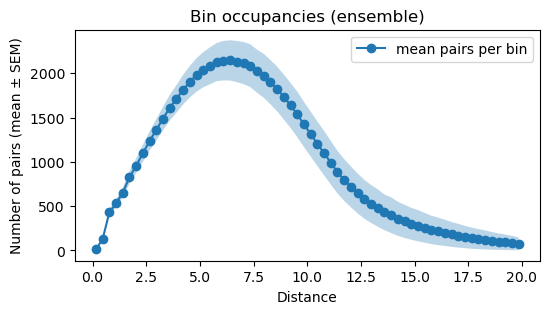

In [118]:
pair_counts_arr = np.stack(pair_counts_all, axis=0)  # (n_org, B)
mean_counts = pair_counts_arr.mean(axis=0)
std_counts = pair_counts_arr.std(axis=0, ddof=1)
sem_counts = std_counts / np.sqrt(pair_counts_arr.shape[0])

plt.figure(figsize=(6,3))
plt.plot(bin_centers, mean_counts, 'o-', label='mean pairs per bin')
plt.fill_between(bin_centers, mean_counts - sem_counts, mean_counts + sem_counts, alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Number of pairs (mean ± SEM)")
plt.title("Bin occupancies (ensemble)")
plt.legend()
plt.show()


In [119]:
# convert lists -> arrays with shape (n_org, B, F, F)
Corr_all = np.stack(Corr_all, axis=0)    # (n_org, B, F, F)
Corr_conn_all = np.stack(Corr_conn_all, axis=0)    # (n_org, B, F, F)
Corr_norm_all = np.stack(Corr_norm_all, axis=0)    # (n_org, B, F, F)


# number of organoids
n_org = Corr_all.shape[0]


In [120]:
import scikits.bootstrap as boot

# Each array has shape (n_org, B, F, F)
corr_dict = {
    "C": np.stack(Corr_all, axis=0),
    "C_conn": np.stack(Corr_conn_all, axis=0),
    "C_norm": np.stack(Corr_norm_all, axis=0),
}

# Pick which field indices you want to analyze, e.g. autocorr of field 0
i, j = 0, 0   # change as needed

# Store results
ci_results = {}

for name, arr in corr_dict.items():
    # extract data across organoids for this (i,j) field pair
    # shape: (n_org, B) → transpose to (B, n_org)
    data = arr[:, :, i, j].T

    ci_low = []
    ci_high = []
    for b in range(data.shape[0]):
        ci = boot.ci(
            data[b], 
            statfunction=np.nanmean, 
            method='bca', 
            alpha=0.05, 
            n_samples=2000
        )
        ci_low.append(ci[0])
        ci_high.append(ci[1])

    ci_results[name] = {
        "low": np.array(ci_low),
        "high": np.array(ci_high)
    }

/tmp/ipykernel_1092790/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_1092790/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_1092790/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_1092790/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_1092790/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_1092790/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_1092790/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = b

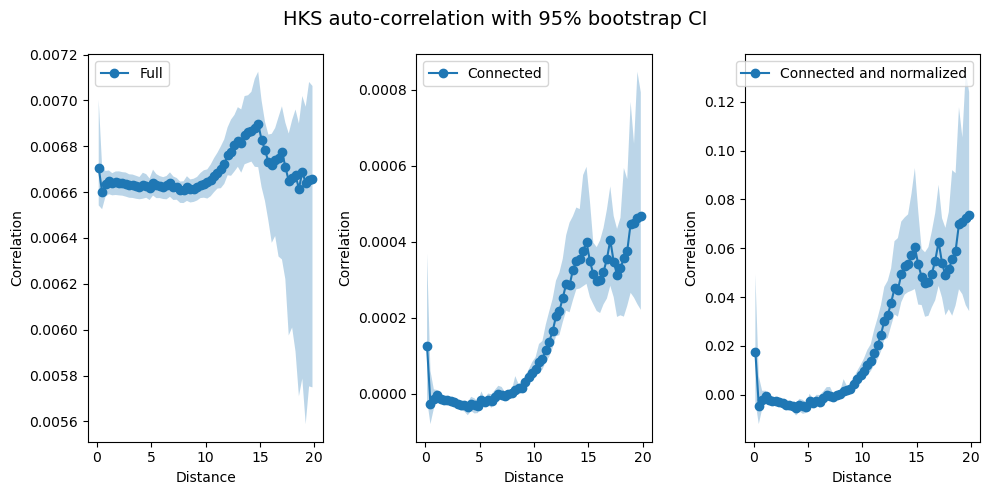

In [121]:
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
mean_C = np.nanmean(corr_dict["C"], axis=0)  # (B,F,F)
plt.plot(bin_centers, mean_C[:,0,0], 'o-', label="Full")
plt.fill_between(
    bin_centers,
    ci_results["C"]["low"],
    ci_results["C"]["high"],
    alpha=0.3
)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()


plt.subplot(1,3,2)
mean_C = np.nanmean(corr_dict["C_conn"], axis=0)  # (B,F,F)
plt.plot(bin_centers, mean_C[:,0,0], 'o-', label="Connected")
plt.fill_between(
    bin_centers,
    ci_results["C_conn"]["low"],
    ci_results["C_conn"]["high"],
    alpha=0.3
)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()


plt.subplot(1,3,3)
mean_C = np.nanmean(corr_dict["C_norm"], axis=0)  # (B,F,F)
plt.plot(bin_centers, mean_C[:,0,0], 'o-', label="Connected and normalized")
plt.fill_between(
    bin_centers,
    ci_results["C_norm"]["low"],
    ci_results["C_norm"]["high"],
    alpha=0.3
)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()

plt.suptitle("HKS auto-correlation with 95% bootstrap CI", fontsize=14)

plt.tight_layout()
plt.show()


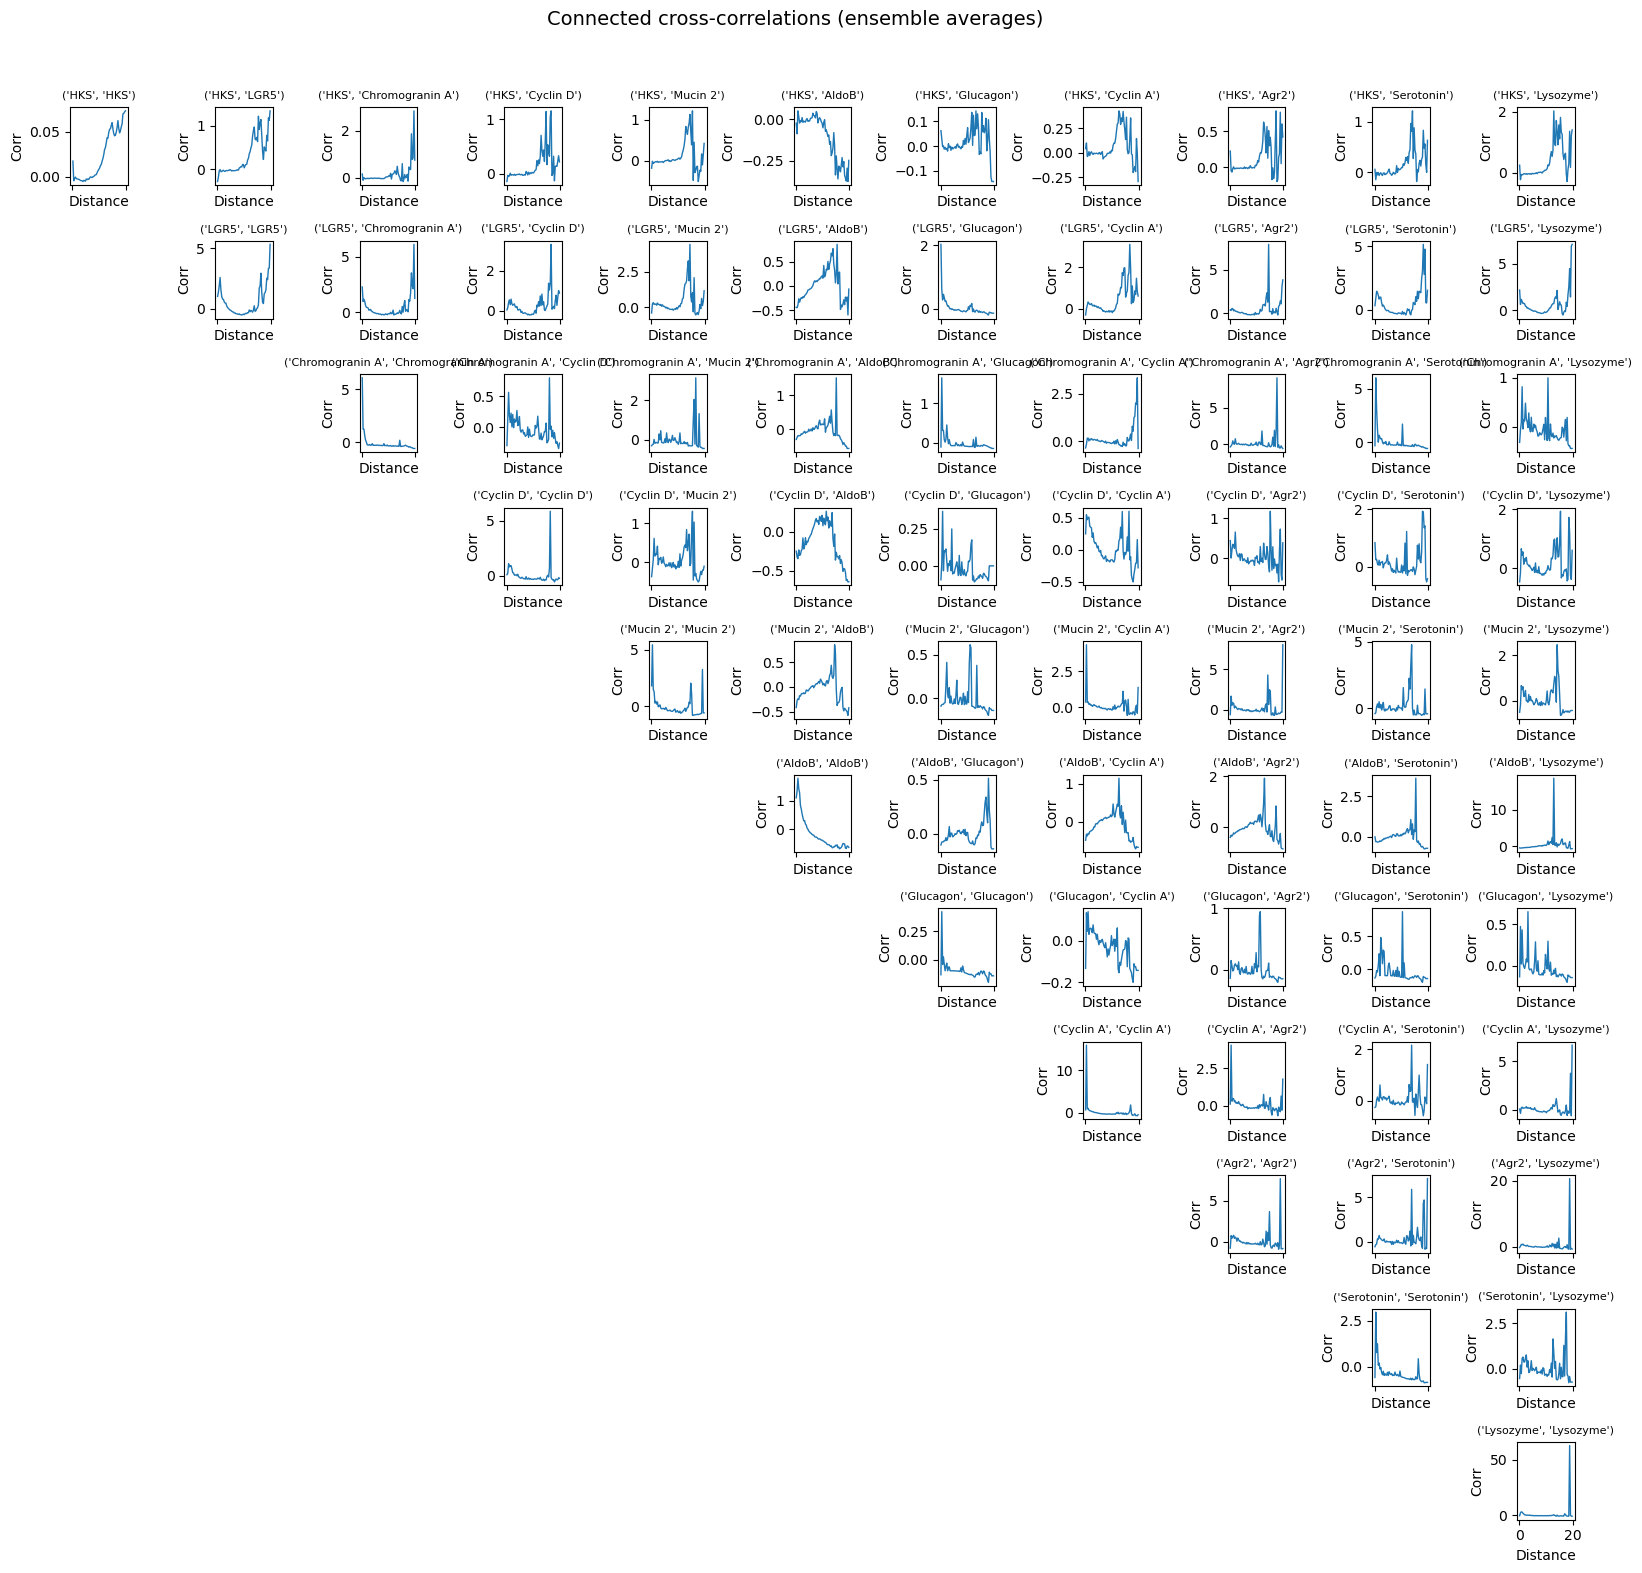

In [122]:
n_org, B, F, _ = Corr_all.shape


fig, axes = plt.subplots(F, F, figsize=(16, 16), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # Plot the four variants
        ax.plot(bin_centers, np.nanmean(Corr_norm_all[:,:,i,j], axis=0),  '-',  lw=1,
                label="Connected" if (i==0 and j==0) else "")
        
        ax.set_title((field_names[i], field_names[j]), fontsize=8)
        ax.set_ylabel("Corr", fontsize=10)
        ax.set_xlabel("Distance", fontsize=10)

# Global labels + legend
fig.suptitle("Connected cross-correlations (ensemble averages)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Group organoids

If the organoids do not develop any protrusions, i.e. they are sphere-like, they will likely show different correlation behavior. Hence it may be worth exploring whether we need to calculate correlations across groups, rather than days. 

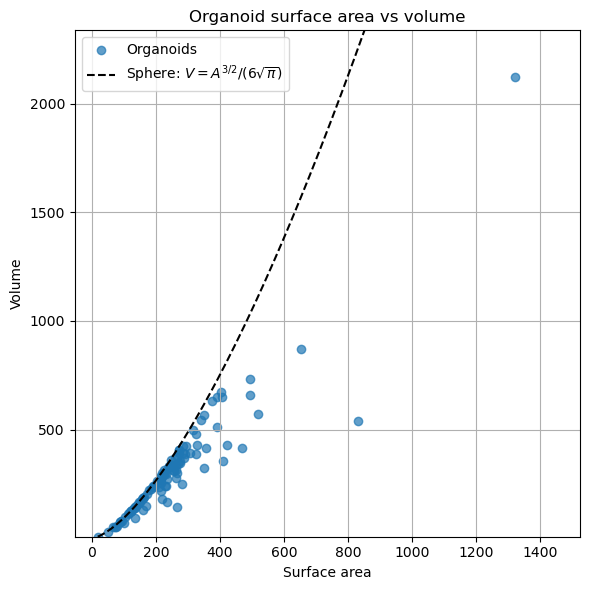

In [123]:
tot_area_all = np.stack(tot_area_all, axis=0)
tot_volume_all = np.stack(tot_volume_all, axis=0)

plt.figure(figsize=(6,6))
plt.scatter(tot_area_all, tot_volume_all, alpha=0.7, label="Organoids")

# Reference curve: sphere relation
A_range = np.linspace(tot_area_all.min()*0.9, tot_area_all.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)

plt.plot(A_range, V_sphere, 'k--', label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

plt.xlabel("Surface area")
plt.ylabel("Volume")
plt.title("Organoid surface area vs volume")
plt.legend()
plt.grid(True)

plt.ylim(tot_volume_all.min()*0.9, tot_volume_all.max()*1.1)
plt.tight_layout()

plt.show()



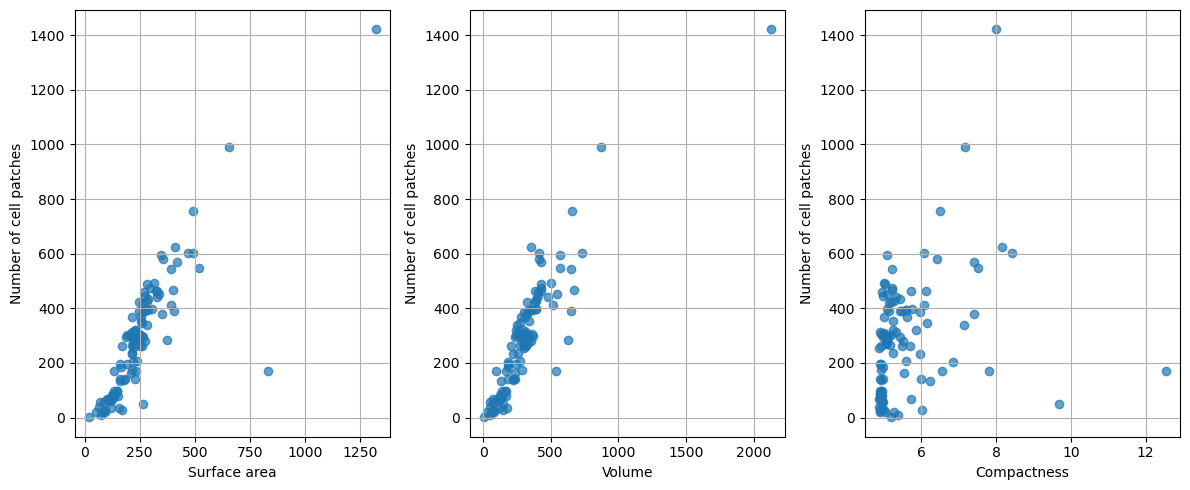

In [124]:
num_cells = np.stack(num_cell_all, axis=0)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.scatter(tot_area_all, num_cells, alpha=0.7)
plt.xlabel("Surface area")
plt.ylabel("Number of cell patches")
plt.grid(True)

plt.subplot(1,3,2)
plt.scatter(tot_volume_all, num_cells, alpha=0.7)
plt.xlabel("Volume")
plt.ylabel("Number of cell patches")
plt.grid(True)


plt.subplot(1,3,3)
plt.scatter(tot_area_all / (tot_volume_all ** (2.0/3.0)), num_cells, alpha=0.7)
plt.xlabel("Compactness")
plt.ylabel("Number of cell patches")
plt.grid(True)

plt.tight_layout()

plt.show()

In [125]:
compactness = tot_area_all / (tot_volume_all ** (2.0/3.0))

comp_sphere = 4.835
threshold = 1.20 * comp_sphere   # 20% larger than sphere
group_sphere_like = (compactness <= threshold) & (tot_volume_all >= 200)
group_protruded   = (compactness > threshold) & (tot_volume_all >= 200)

print(np.sum(group_sphere_like))
print(np.sum(group_protruded))

58
19


/tmp/ipykernel_1092790/1834834133.py:1: RuntimeWarning: Mean of empty slice
  Corr_sphere = np.nanmean(Corr_norm_all[group_sphere_like], axis=0)    # (B,F,F)


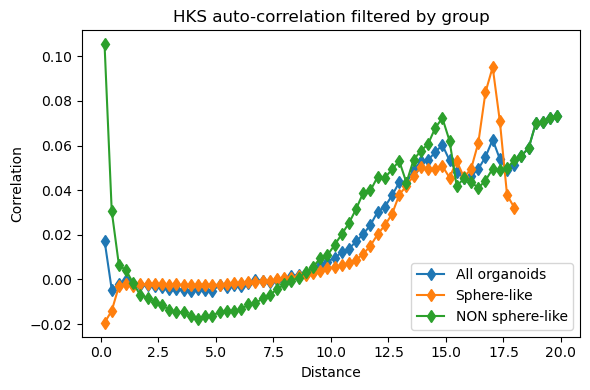

In [126]:
Corr_sphere = np.nanmean(Corr_norm_all[group_sphere_like], axis=0)    # (B,F,F)
Corr_protruded = np.nanmean(Corr_norm_all[group_protruded], axis=0)    # (B,F,F)

plt.figure(figsize=(6,4))
# Equal, raw field
plt.plot(bin_centers, np.nanmean(Corr_norm_all[:,:,0,0], axis=0), 'd-', label="All organoids")
plt.plot(bin_centers, Corr_sphere[:,0,0], 'd-', label="Sphere-like")
plt.plot(bin_centers, Corr_protruded[:,0,0], 'd-', label="NON sphere-like")

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("HKS auto-correlation filtered by group")
plt.legend()
plt.tight_layout()
plt.show()

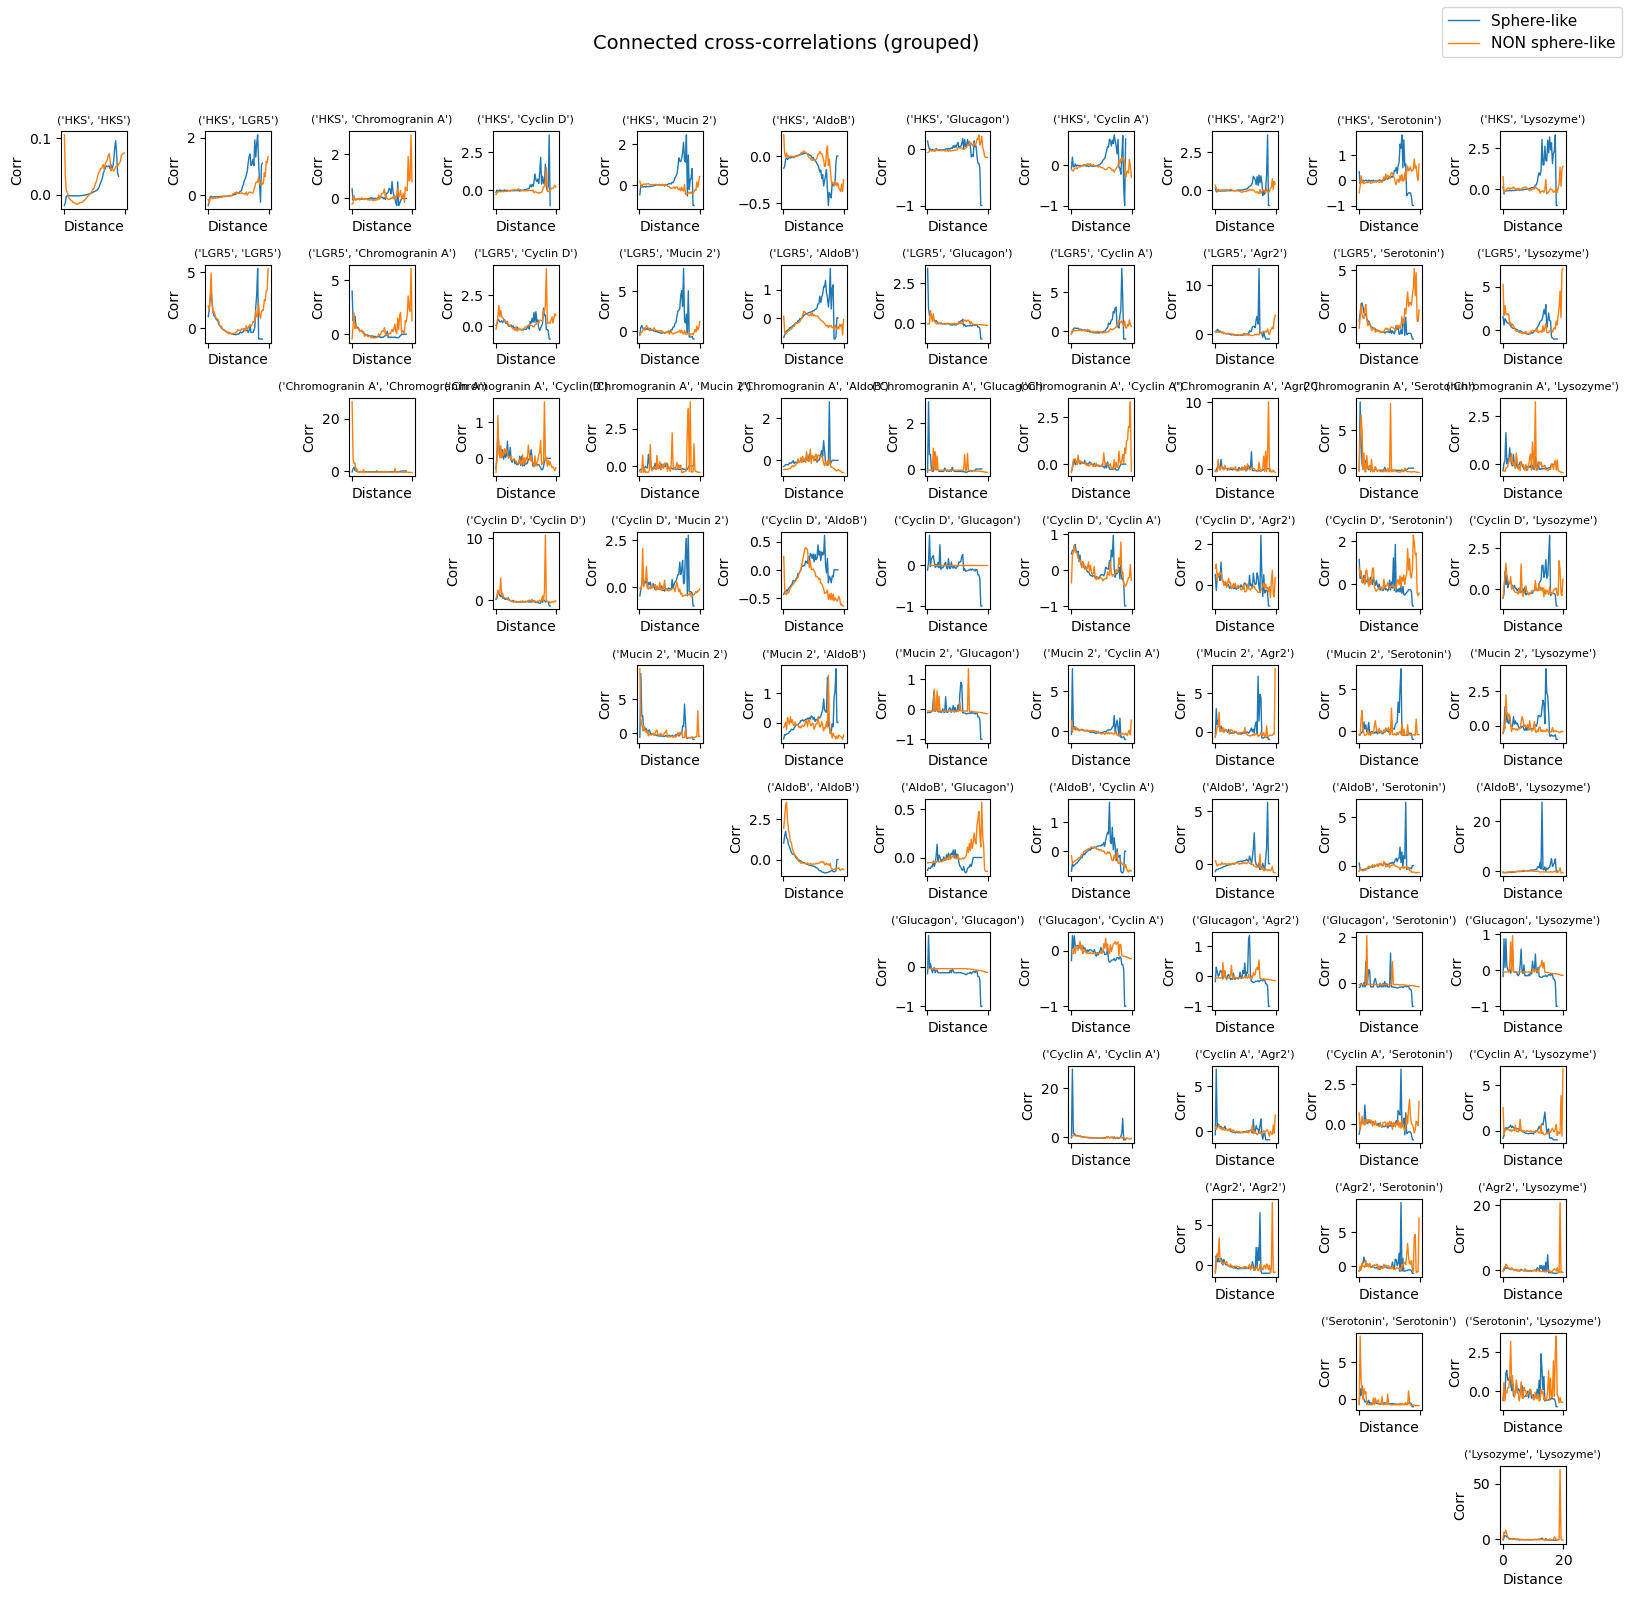

In [127]:
n_org, B, F, _ = Corr_all.shape

fig, axes = plt.subplots(F, F, figsize=(16, 16), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # # Plot the four variants
        # ax.plot(bin_centers, np.nanmean(Corr_conn_all[:,:,i,j], axis=0),  '-',  lw=1,
        #         label="All organoids" if (i==0 and j==0) else "")
        
        ax.plot(bin_centers, Corr_sphere[:,i,j],  '-',  lw=1,
                label="Sphere-like" if (i==0 and j==0) else "")
        
        ax.plot(bin_centers, Corr_protruded[:,i,j],  '-',  lw=1,
                label="NON sphere-like" if (i==0 and j==0) else "")
        
        
        ax.set_title((field_names[i], field_names[j]), fontsize=8)
        ax.set_ylabel("Corr", fontsize=10)
        ax.set_xlabel("Distance", fontsize=10)

# Global labels + legend
fig.suptitle("Connected cross-correlations (grouped)", fontsize=14)
fig.legend(loc="upper right", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


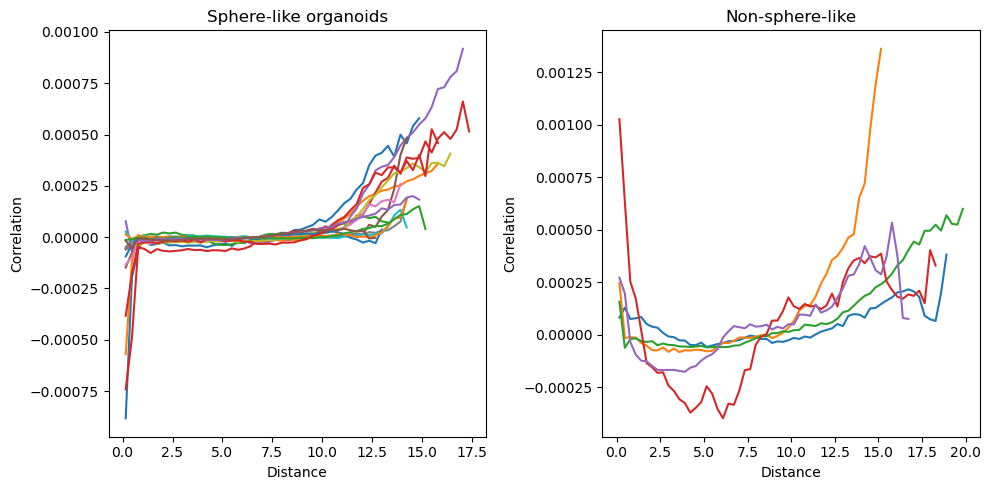

In [128]:
# Get orgnaoids with similar colume from the two groups
vol_min = 350
vol_max = 500

group_sph_vol = (compactness <= threshold) & (tot_volume_all >= vol_min) & (tot_volume_all <= vol_max)
group_pro_vol   = (compactness > threshold) & (tot_volume_all >= vol_min) & (tot_volume_all <= vol_max)


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(bin_centers, Corr_conn_all[group_sph_vol,:,0,0].T)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Sphere-like organoids")


plt.subplot(1,2,2)
plt.plot(bin_centers, Corr_conn_all[group_pro_vol,:,0,0].T)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Non-sphere-like")

plt.tight_layout()
plt.show()


In [129]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.manifold import MDS
from sklearn.cluster import KMeans


def cluster_correlations(C_all, threshold = 0.8, k=2):

    # C_all: (n_org, B) correlation curves (NaNs at long distances)
    n_org, B = C_all.shape

    # 1) compute coverage per bin
    valid_counts = np.sum(~np.isnan(C_all), axis=0)   # shape (B,)
    frac = valid_counts / n_org

    # 2) choose bins where fraction >= threshold
    mask_bins = frac >= threshold
    print("Using", mask_bins.sum(), "bins out of", B)

    # 3) build feature matrix truncated
    X = C_all[:, mask_bins]

    # 4) for each organoid, if there are still NaNs inside truncated region (rare), impute with linear interp or fill with bin mean
    for i in range(n_org):
        row = X[i]
        if np.isnan(row).any():
            # linear interp across available points
            good = ~np.isnan(row)
            if good.sum() >= 2:
                xp = np.where(good)[0]
                fp = row[good]
                x = np.arange(len(row))
                X[i] = np.interp(x, xp, fp)
            else:
                # fallback: fill with zeros
                X[i] = np.nan_to_num(row, nan=0.0)

    # 5) standardize per-sample (z-score) or globally. Here per-sample:
    # Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, ddof=1, keepdims=True) + 1e-12)
    Xz = (X ) / (X.std(axis=1, ddof=1, keepdims=True) + 1e-12)
    # Xz = (X ) / (X.mean(axis=1, keepdims=True) + 1e-12)
    # Xz = X

    # 6) cluster
    km = KMeans(n_clusters=k, random_state=0).fit(Xz)
    labels = km.labels_

    return km, labels, mask_bins, Xz

Using 35 bins out of 64
18
82


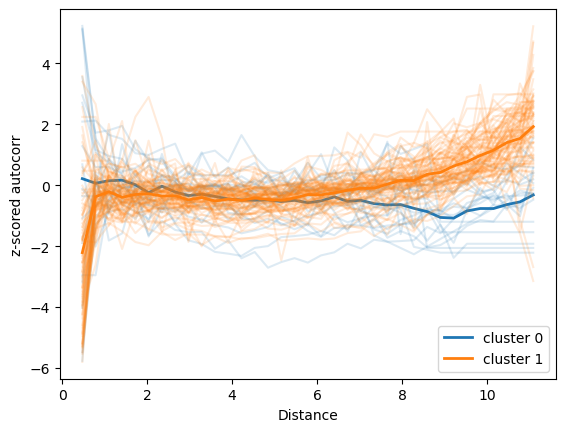

In [130]:
vol_min = 100
C_cluster = Corr_norm_all[tot_volume_all>vol_min,:,0,0]

km, labels, mask_bins, Cz = cluster_correlations(C_cluster, k=2, threshold=0.8)


centroids = km.cluster_centers_
r_plot = bin_centers[mask_bins]
plt.figure()
for c in range(km.n_clusters):
    members = Cz[labels==c]

    print(members.shape[0])

    # plot member curves lightly
    for row in members:
        plt.plot(r_plot, row, color=f"C{c}", alpha=0.15)
    # plot centroid
    plt.plot(r_plot, centroids[c], color=f"C{c}", lw=2, label=f"cluster {c}")
plt.legend()
plt.xlabel("Distance")
plt.ylabel("z-scored autocorr")
plt.show()

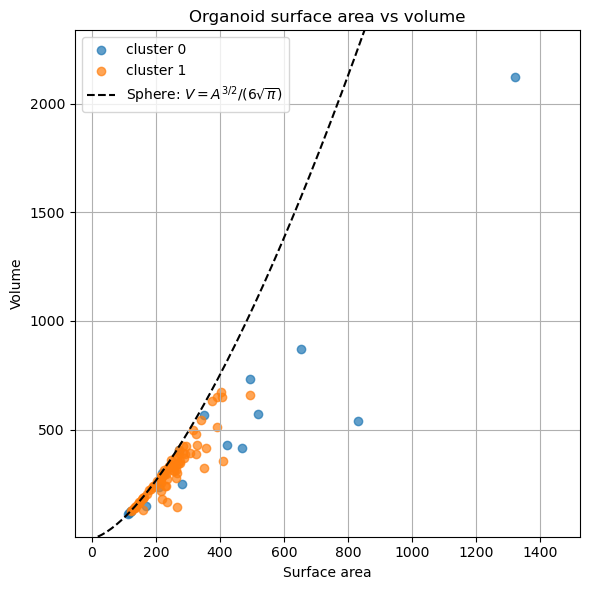

In [131]:
tot_area_tmp = tot_area_all[tot_volume_all>vol_min]
tot_volume_tmp = tot_volume_all[tot_volume_all>vol_min]

plt.figure(figsize=(6,6))
for c in range(km.n_clusters):
    plt.scatter(tot_area_tmp[labels==c], tot_volume_tmp[labels==c], color=f"C{c}", alpha=0.7, label=f"cluster {c}")

# Reference curve: sphere relation
A_range = np.linspace(tot_area_all.min()*0.9, tot_area_all.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)

plt.plot(A_range, V_sphere, 'k--', label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

plt.xlabel("Surface area")
plt.ylabel("Volume")
plt.title("Organoid surface area vs volume")
plt.legend()
plt.grid(True)

plt.ylim(tot_volume_all.min()*0.9, tot_volume_all.max()*1.1)
plt.tight_layout()

plt.show()

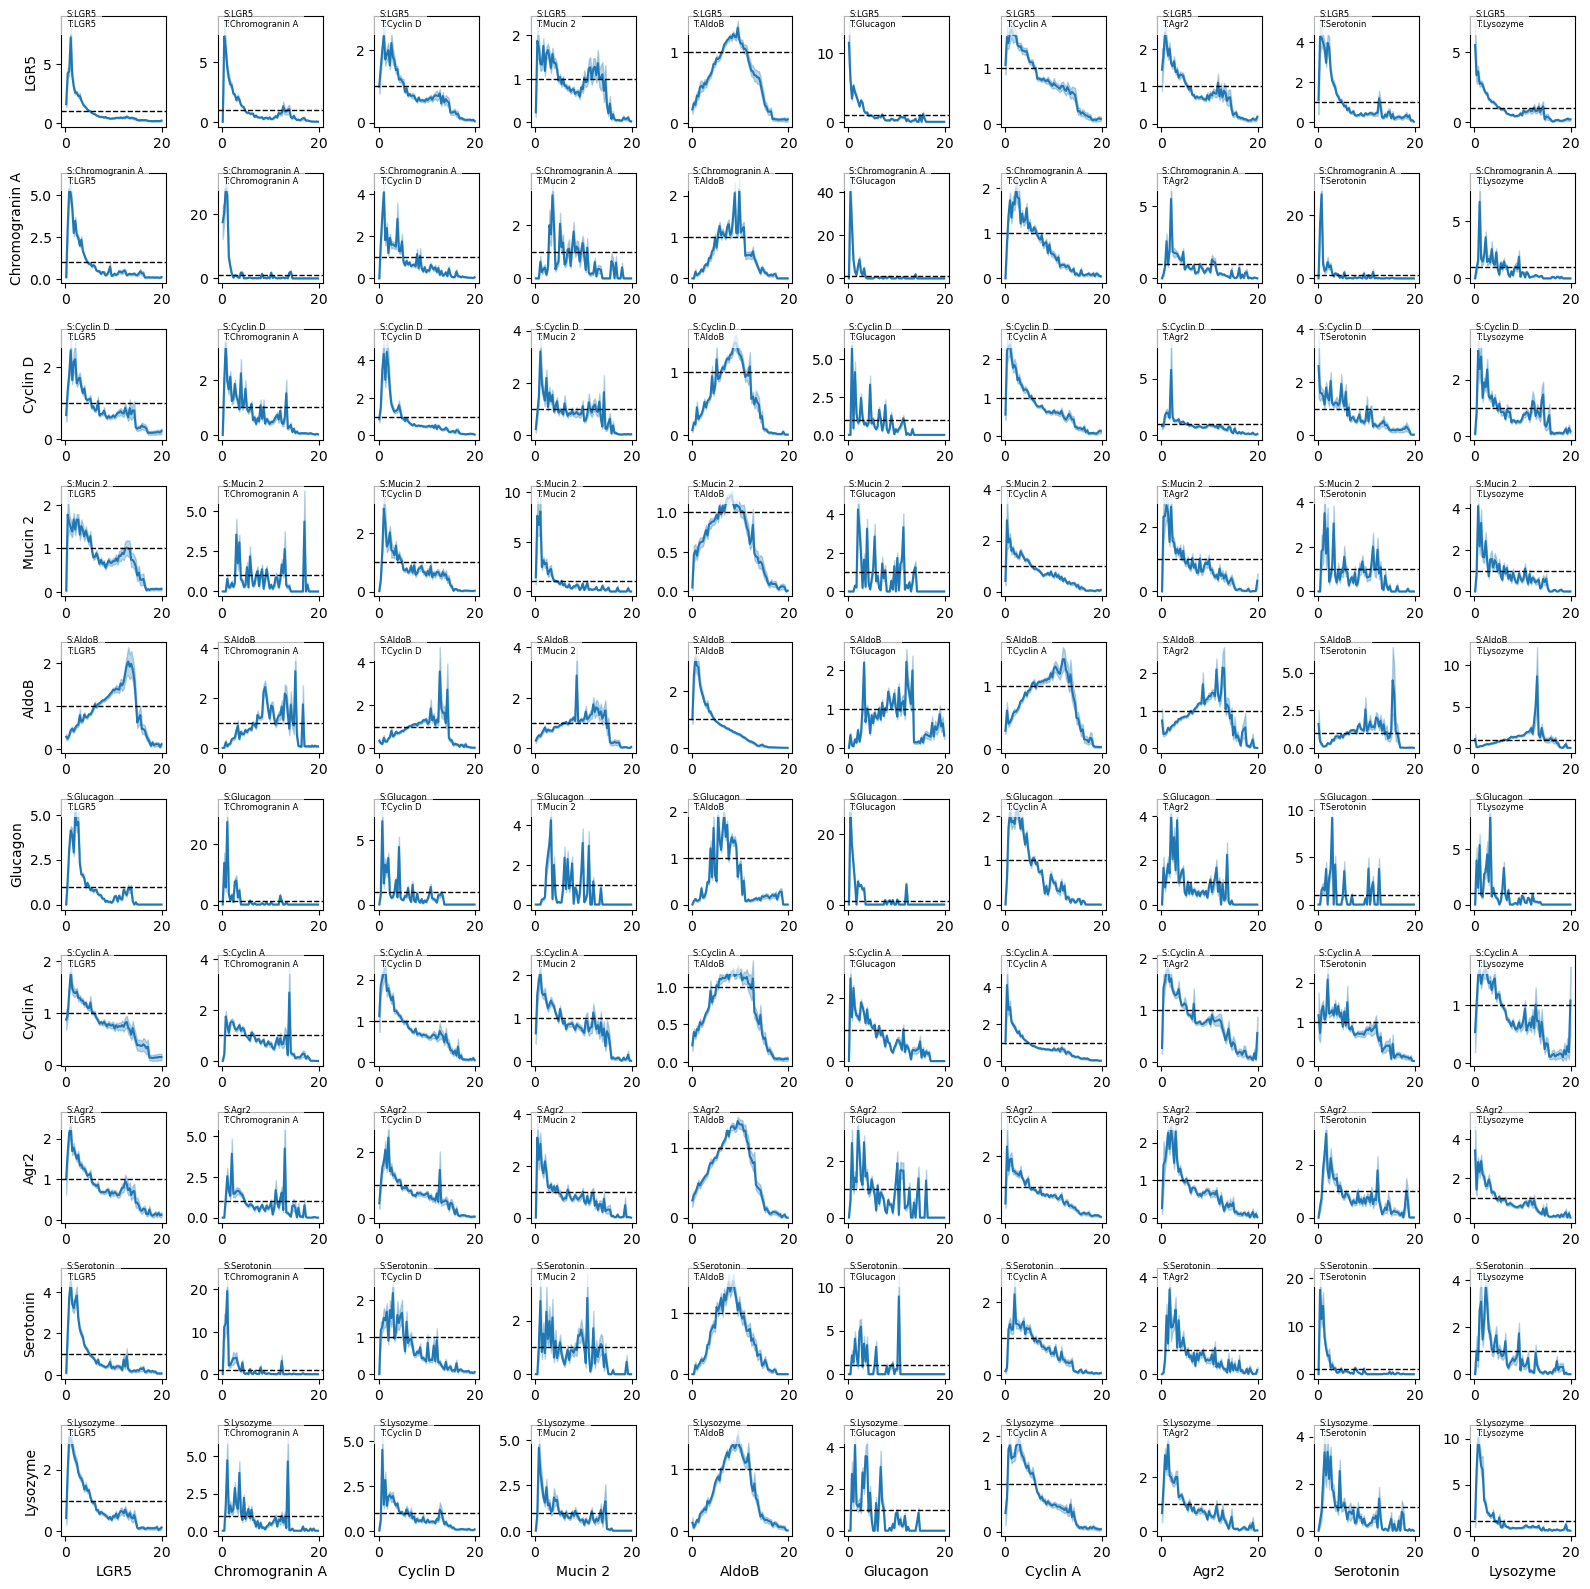

In [132]:

# Convert list to ndarray
Enrichment_arr = np.stack(Enrichment_all, axis=0)

n_organoids, n_markers, nbins, _ = Enrichment_arr.shape

# Skip first marker (index 0)
field_names_subset = field_names[1:]

# Ensemble mean and SEM
Enrichment_mean = np.nanmean(Enrichment_arr[:, 1:, :, 1:], axis=0)  # (nbins, n_markers-1)
Enrichment_std  = np.nanstd(Enrichment_arr[:, 1:, :, 1:], axis=0)
Enrichment_sem  = Enrichment_std / np.sqrt(n_organoids)

n_plot_markers = n_markers-1

# -------------------- Plot cross-enrichment grid --------------------
fig, axes = plt.subplots(n_plot_markers, n_plot_markers,
                         figsize=(16, 16),
                         sharex=False, sharey=False)

for i_source in range(n_plot_markers):
    for j_target in range(n_plot_markers):
        ax = axes[i_source, j_target]

        # Plot ensemble-averaged enrichment
        ax.plot(bin_centers, Enrichment_mean[i_source, :, j_target], color='tab:blue')
        ax.fill_between(bin_centers,
                        Enrichment_mean[i_source, :, j_target] - Enrichment_sem[i_source, :, j_target],
                        Enrichment_mean[i_source, :, j_target] + Enrichment_sem[i_source, :, j_target],
                        alpha=0.3, color='tab:blue')

        ax.axhline(1.0, color='k', linestyle='--', linewidth=1)

        # Axis labels
        if i_source == n_plot_markers - 1:
            ax.set_xlabel(f"{field_names_subset[j_target]}", fontsize=10)
        if j_target == 0:
            ax.set_ylabel(f"{field_names_subset[i_source]}", fontsize=10)

        ax.tick_params(axis='both', which='major', labelsize=10)

        # Add label inside subplot for quick identification
        ax.text(0.05, 0.9, f"S:{field_names_subset[i_source]}\nT:{field_names_subset[j_target]}",
                transform=ax.transAxes, fontsize=6, color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()


(0.0, 10.0)

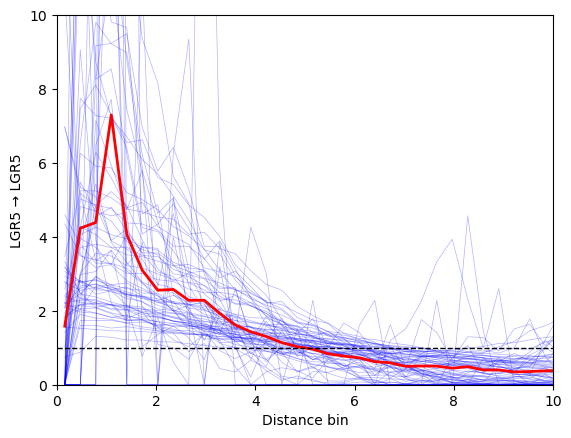

In [135]:
# --- Choose one source and one target ---
i_source = 0   # e.g. index in field_names_subset
j_target = 0   # e.g. index in field_names_subset



curves = Enrichment_arr[:, i_source+1, :, j_target+1]

# Plot each organoid curve (thin, transparent)
for c in curves:
    plt.plot(bin_centers, c, color="blue", linewidth=0.5, alpha=0.3)

# Compute mean curve
mean_curve = np.nanmean(curves, axis=0)

# Plot mean (thicker)
plt.plot(bin_centers, mean_curve, color="red", linewidth=2, label="Mean")

# Horizontal line at 1
plt.axhline(1.0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Distance bin")
plt.ylabel(f"{field_names_subset[i_source]} → {field_names_subset[j_target]}")

plt.xlim((0, 10))
plt.ylim((0, 10))
